In [2]:
import pandas as pd

df = pd.read_csv("../data/cleaned_data.csv")
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

df['hour'] = df.index.hour
df['day'] = df.index.dayofweek
df['month'] = df.index.month

df['lag_1'] = df['-Global_active_power'].shift(1)
df['lag_2'] = df['-Global_active_power'].shift(2)
df['lag_24'] = df['-Global_active_power'].shift(24)

df = df.dropna()

In [4]:
X = df.drop(columns=['-Global_active_power'])
y = df['-Global_active_power']

In [5]:
split = int(len(df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[-0.17, 0. , 0.23,..., 0.02,-0. , 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['Global_reactive_power','Voltage','Global_intensity',...,'lag_1','lag_2', 'lag_24']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.076
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


In [7]:
y_pred = model.predict(X_test)


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.023376640420950664
RMSE: 0.03853932396098545


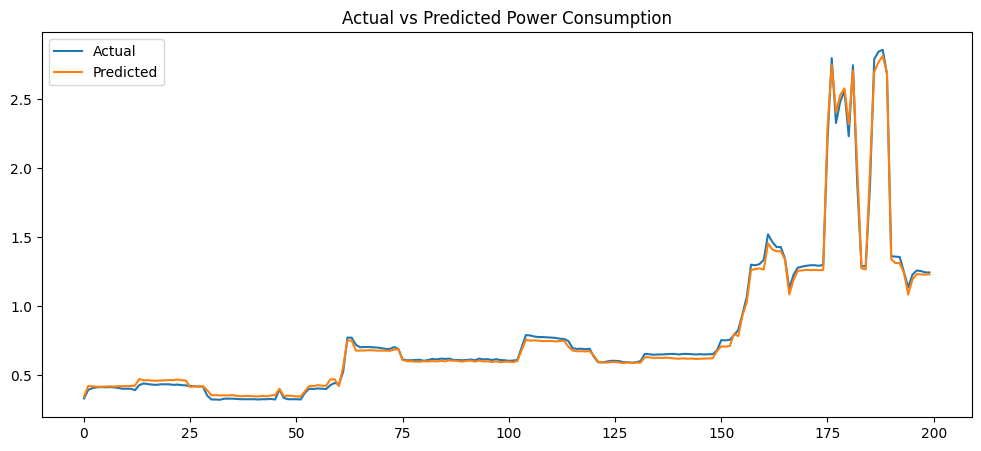

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Power Consumption")

plt.savefig("../images/lr_prediction.png")
plt.show()

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 0.026156670919849398


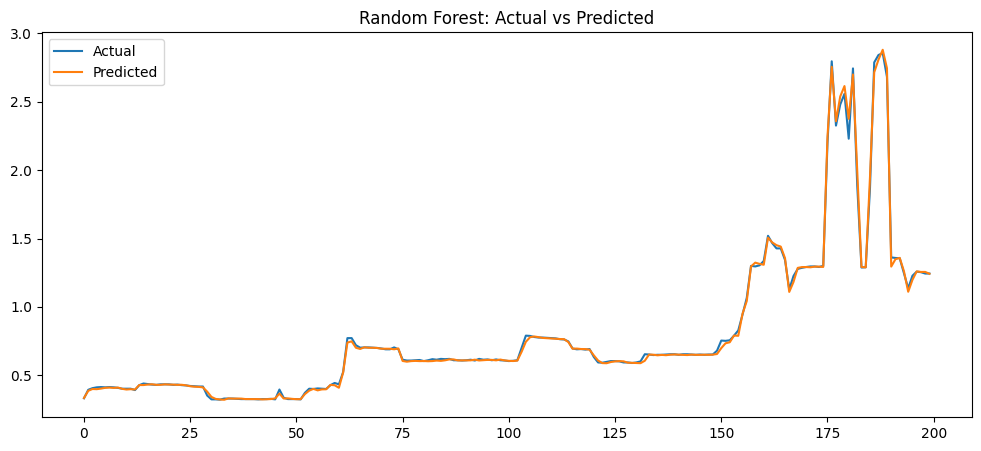

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred_rf[:200], label='Predicted')

plt.legend()
plt.title("Random Forest: Actual vs Predicted")

plt.savefig("../images/rf_prediction.png")
plt.show()

In [15]:
print("Linear Regression RMSE:", rmse)
print("Random Forest RMSE:", rmse_rf)

Linear Regression RMSE: 0.03853932396098545
Random Forest RMSE: 0.026156670919849398
